# NBA Graph Strategy — Exploration

End-to-end view: data → three networks → utility network → mispricing → backtest.
Inline knobs in each modelling section so you can iterate without editing modules.

## 0 — Setup

In [1]:
import sys, sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import DB_PATH, SEASONS
from src.network.builders import build_passing_network, build_lineup_network, build_team_network
from src.network.utility_net import build_utility_network
from src.network.metrics import summarize, communities

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


## 1 — Data overview

In [2]:
conn = sqlite3.connect(DB_PATH)
tables = [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name").fetchall()]
inv = pd.DataFrame([{"table": t, "rows": conn.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0]} for t in tables])
display(inv.sort_values("rows", ascending=False))
conn.close()

,table,rows
1,lineup_stats_base,436472
0,lineup_stats_advanced,209574
4,passing_received,94992
3,passing_made,94891
5,player_stats_advanced,7411
6,player_stats_base,7411
2,passing_external,5318
7,team_season_features,420
8,team_stats_advanced,420
9,team_stats_base,420


## 2 — Passing network (BOS 2023-24)

In [3]:
SEASON, TEAM = "2023-24", "BOS"
G = build_passing_network(SEASON, TEAM)
pd.Series(summarize(G)).round(3)


n_nodes                      19.000
n_edges                     216.000
n_components                  1.000
efficiency                   84.440
degree_entropy                2.331
n_communities                 2.000
modularity_largest_share      0.684
resilience_drop3              0.465
dtype: float64

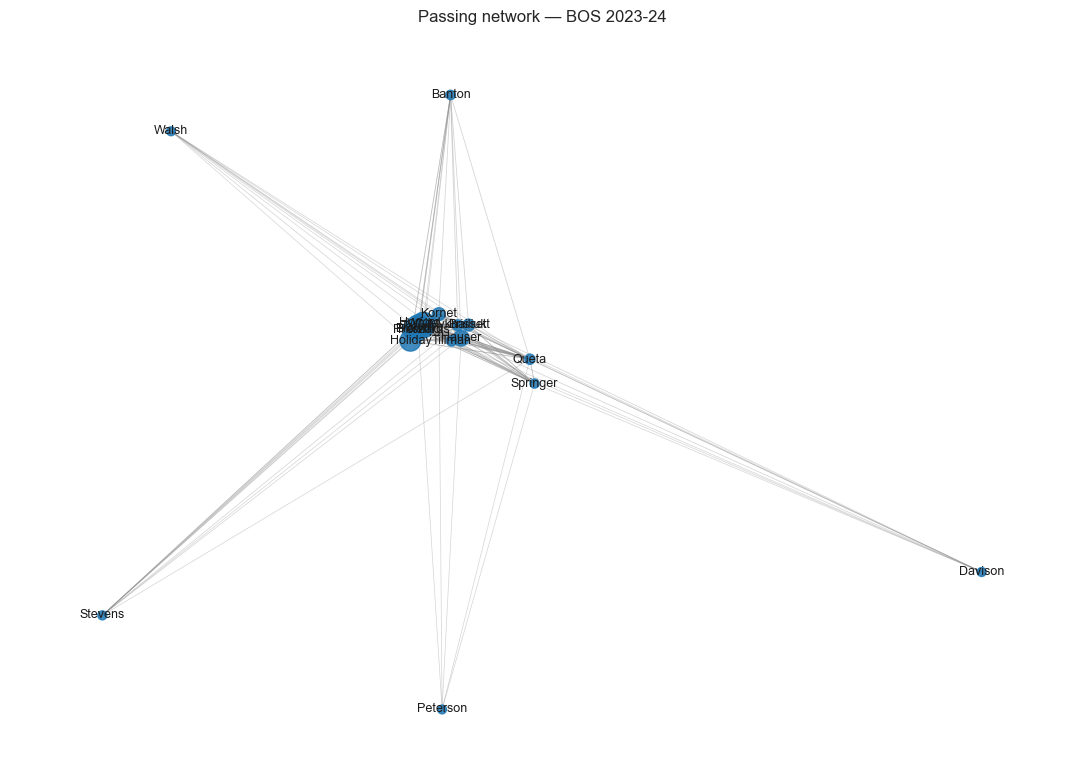

In [4]:
pos = nx.spring_layout(G, seed=7, k=1.2/np.sqrt(max(G.number_of_nodes(),1)))
deg = dict(G.degree(weight="weight"))
node_sizes = [40 + deg[n]/30 for n in G.nodes]
edge_widths = [0.5 + d["weight"]/200 for _,_,d in G.edges(data=True)]
labels = {n: G.nodes[n]["name"].split(",")[0] for n in G.nodes}

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.35, edge_color="#888", arrows=False, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#1f77b4", alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)
ax.set_title(f"Passing network — {TEAM} {SEASON}")
ax.axis("off")
plt.tight_layout()


## 2.5 — Passing network deep dive (Yang feedback 2026-05-20)

Per Dr. Yang's review (2026-05-20):

- **Edge weighting**: raw `n_pass` lets a few heavy edges dominate. Try `weight = 1/n_pass` (treats high-pass-count as "short distance") or normalize (`log`, `zscore`) before building the network.
- **Community detection**: estimate `n_communities` per team with Louvain.
- **Layout**: community-aware placement instead of vanilla spring layout.
- **Node metrics**: inflow, outflow, centralities.
- **Team metrics**: avg in/out strength, avg degree, entropy, n_communities.
- **Hypothesis**: strong teams have more communities + higher centrality/entropy/avg degree. Offensive cores (LeBron-type) show high inflow.

Lineup work (2/3-man instead of 5-man) is deferred to Section 3 since it requires re-fetching from nba_api with `group_quantity` ∈ {2, 3}.


In [5]:
from networkx.algorithms.community import louvain_communities
from src.network.metrics import degree_entropy


def passing_graph(season, team, weight_mode="inverse", min_mpg=0.0):
    """Build directed passing graph with a chosen edge-weight transform.

    weight_mode:
      - 'raw'     : weight = n_pass                (baseline)
      - 'log'     : weight = log(1 + n_pass)       (compresses heavy edges)
      - 'zscore'  : z-score of n_pass, shifted positive
      - 'inverse' : weight = 1 / n_pass            (Yang: small = strong link)

    min_mpg:
      Drop players averaging fewer than this many minutes per game (joined
      from player_stats_base, MEASURE_TYPE='Base'). Set to 0 to keep everyone.
      Yang flagged that deep-bench / churn players inflate entropy & community
      count, so filtering to the rotation is part of the same idea behind
      using 2/3-man lineups instead of 5.
    """
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(
        "SELECT PLAYER_ID, PLAYER_NAME_LAST_FIRST, PASS_TEAMMATE_PLAYER_ID, "
        "PASS_TO, PASS FROM passing_made "
        "WHERE SEASON=? AND TEAM_ABBREVIATION=? AND PASS>0",
        conn, params=(season, team),
    )
    if min_mpg > 0:
        mins = pd.read_sql_query(
            "SELECT PLAYER_ID, MIN FROM player_stats_base "
            "WHERE SEASON=? AND TEAM_ABBREVIATION=? AND MEASURE_TYPE='Base'",
            conn, params=(season, team),
        )
        keep = set(mins.loc[mins["MIN"] >= min_mpg, "PLAYER_ID"].astype(int))
        df = df[
            df["PLAYER_ID"].astype(int).isin(keep)
            & df["PASS_TEAMMATE_PLAYER_ID"].astype(int).isin(keep)
        ]
    conn.close()

    g = nx.DiGraph(season=season, team=team, weight_mode=weight_mode, min_mpg=min_mpg)
    if df.empty:
        return g

    n = df["PASS"].astype(float).to_numpy()
    if weight_mode == "raw":
        w = n
    elif weight_mode == "log":
        w = np.log1p(n)
    elif weight_mode == "zscore":
        mu, sd = n.mean(), n.std(ddof=0) or 1.0
        w = (n - mu) / sd
        w = w - w.min() + 1e-6
    elif weight_mode == "inverse":
        w = 1.0 / n
    else:
        raise ValueError(weight_mode)

    names = {}
    for (pid, pname, tid, tname), wi, ni in zip(
        df[["PLAYER_ID", "PLAYER_NAME_LAST_FIRST",
            "PASS_TEAMMATE_PLAYER_ID", "PASS_TO"]].itertuples(index=False, name=None),
        w, n,
    ):
        names.setdefault(int(pid), pname)
        names.setdefault(int(tid), tname)
        g.add_edge(int(pid), int(tid), weight=float(wi), n_pass=float(ni))
    for nd in g.nodes:
        g.nodes[nd]["name"] = names.get(nd, str(nd))
    return g


def louvain_partition(g, weight="weight", seed=0):
    """Louvain communities on the undirected projection. Returns list[set]."""
    h = g.to_undirected() if g.is_directed() else g
    if h.number_of_nodes() == 0:
        return []
    return louvain_communities(h, weight=weight, seed=seed)


### Compare weighting modes

Same team, four different edge-weight transforms. Look for the partition that has a sensible number of communities (not 1, not 19).


In [6]:
SEASON, TEAM = "2023-24", "BOS"

mode_rows = []
for mode in ["raw", "log", "zscore", "inverse"]:
    g = passing_graph(SEASON, TEAM, weight_mode=mode)
    comms = louvain_partition(g, seed=0)
    h = g.to_undirected()
    mode_rows.append({
        "weight_mode": mode,
        "n_nodes": g.number_of_nodes(),
        "n_edges": g.number_of_edges(),
        "n_communities": len(comms),
        "largest_comm_share": max((len(c) for c in comms), default=0) / max(g.number_of_nodes(), 1),
        "degree_entropy": degree_entropy(h, weight="weight"),
    })
pd.DataFrame(mode_rows)


,weight_mode,n_nodes,n_edges,n_communities,largest_comm_share,degree_entropy
0,raw,19,216,2,0.684211,2.370937
1,log,19,216,2,0.631579,2.807688
2,zscore,19,216,2,0.684211,2.353926
3,inverse,19,216,4,0.315789,2.826575


### Community-aware layout

Place each Louvain community on a circle, then layout intra-community with spring. Edge thickness = raw passes; node size = inflow strength.


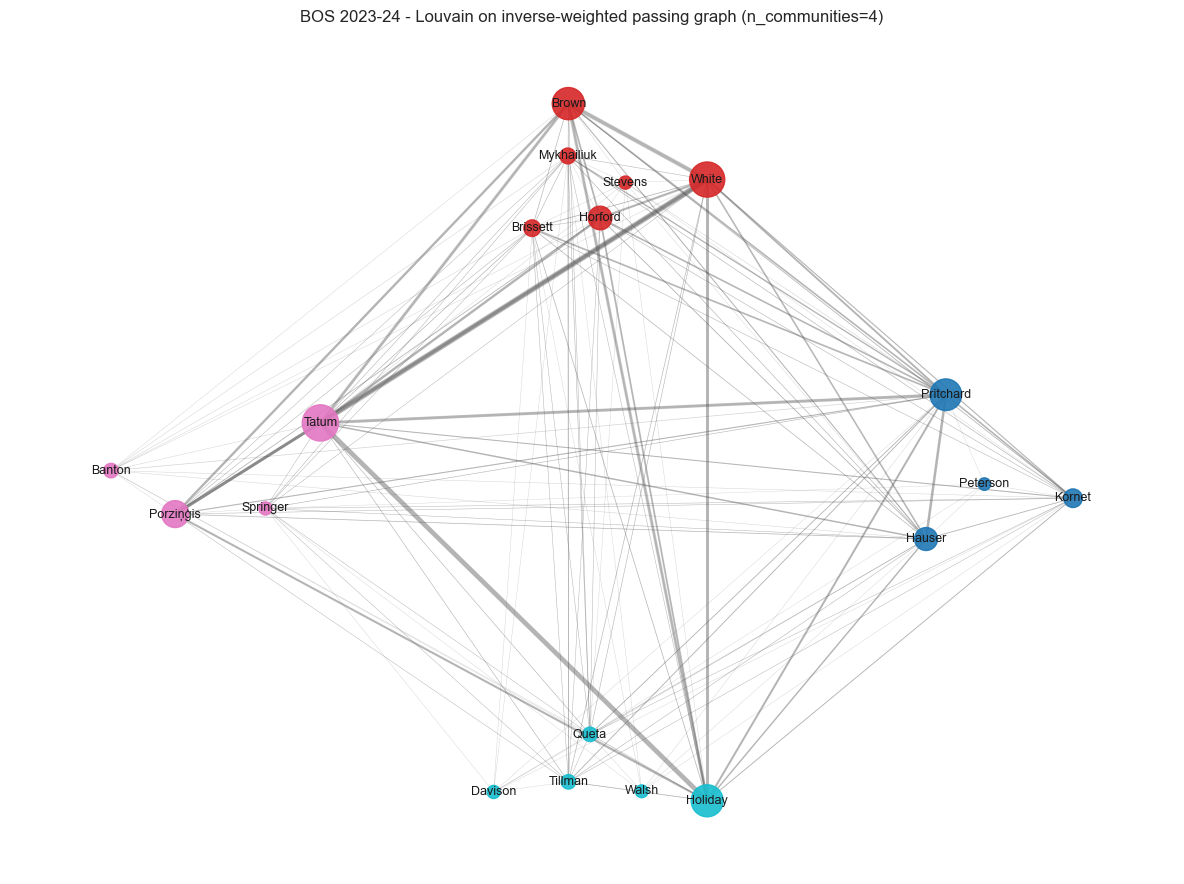

In [7]:
def community_layout(g, communities, seed=7, cluster_scale=2.5, inner_scale=0.7):
    """Place communities on a circle, then run spring layout *within* each.

    Surfaces the partition visually without obliterating intra-community structure.
    """
    h = g.to_undirected() if g.is_directed() else g
    n_c = max(len(communities), 1)
    centers = {
        i: np.array([np.cos(2 * np.pi * i / n_c), np.sin(2 * np.pi * i / n_c)]) * cluster_scale
        for i in range(n_c)
    }
    pos = {}
    for i, c in enumerate(communities):
        sub = h.subgraph(c)
        if sub.number_of_nodes() == 1:
            (node,) = list(sub.nodes)
            pos[node] = centers[i]
            continue
        sub_pos = nx.spring_layout(sub, seed=seed, k=0.5, weight="weight")
        for node, p in sub_pos.items():
            pos[node] = np.array(p) * inner_scale + centers[i]
    return pos


# Inverse weights give Louvain a natural geometric meaning (smaller = stronger link)
g_inv = passing_graph(SEASON, TEAM, weight_mode="inverse")
g_raw = passing_graph(SEASON, TEAM, weight_mode="raw")
comms = louvain_partition(g_inv, seed=0)
comm_of = {n: i for i, c in enumerate(comms) for n in c}

pos = community_layout(g_inv, comms, seed=7)
in_strength = dict(g_raw.in_degree(weight="weight"))
node_sizes = [80 + in_strength.get(n, 0) / 6 for n in g_inv.nodes]
node_colors = [comm_of[n] for n in g_inv.nodes]
edge_widths = [0.3 + g_raw[u][v]["weight"] / 250 for u, v in g_inv.edges() if g_raw.has_edge(u, v)]
labels = {n: g_inv.nodes[n]["name"].split(",")[0].strip() for n in g_inv.nodes}

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_edges(g_inv, pos, width=edge_widths, alpha=0.25,
                       edge_color="#555", arrows=False, ax=ax)
nx.draw_networkx_nodes(g_inv, pos, node_size=node_sizes,
                       node_color=node_colors, cmap="tab10", alpha=0.9, ax=ax)
nx.draw_networkx_labels(g_inv, pos, labels=labels, font_size=9, ax=ax)
ax.set_title(f"{TEAM} {SEASON} - Louvain on inverse-weighted passing graph (n_communities={len(comms)})")
ax.axis("off")
plt.tight_layout()


### Node-level metrics

Dr. Yang's hypothesis: the offensive core has high inflow. For BOS 2023-24 we expect Tatum / Brown / Jrue at the top of `in_strength`.


In [8]:
# Node-level: inflow / outflow / centralities. Use raw weights for strength;
# inverse weights for betweenness (shortest-path on "costs").
g_raw = passing_graph(SEASON, TEAM, weight_mode="raw")
g_inv = passing_graph(SEASON, TEAM, weight_mode="inverse")
comms = louvain_partition(g_inv, seed=0)
comm_of = {n: i for i, c in enumerate(comms) for n in c}

betw = nx.betweenness_centrality(g_inv, weight="weight", normalized=True)
# PageRank is the directed-graph-native analogue of eigenvector centrality —
# robust on non-strongly-connected graphs where eigenvector_centrality_numpy fails.
pr = nx.pagerank(g_raw, weight="weight", alpha=0.85)

node_df = pd.DataFrame([
    {
        "player": g_raw.nodes[n]["name"],
        "community": comm_of.get(n, -1),
        "in_strength": g_raw.in_degree(n, weight="weight"),
        "out_strength": g_raw.out_degree(n, weight="weight"),
        "degree": g_raw.degree(n),
        "betweenness": betw.get(n, 0.0),
        "pagerank": pr.get(n, 0.0),
    }
    for n in g_raw.nodes
]).sort_values("in_strength", ascending=False).reset_index(drop=True)

print("Yang hypothesis check: offensive core = highest inflow")
display(node_df.head(10))


Yang hypothesis check: offensive core = highest inflow


,player,community,in_strength,out_strength,degree,betweenness,pagerank
0,"Tatum, Jayson",2,3607.0,3601.0,28,0.251634,0.142269
1,"White, Derrick",1,3361.0,3342.0,28,0.055556,0.135083
2,"Brown, Jaylen",1,2745.0,2008.0,25,0.000000,0.106854
3,"Holiday, Jrue",3,2713.0,2732.0,27,0.000000,0.109418
4,"Pritchard, Payton",0,2627.0,2539.0,31,0.601307,0.114565
5,"Porziņģis, Kristaps",2,1783.0,1662.0,24,0.000000,0.076373
6,"Horford, Al",1,1250.0,1631.0,25,0.000000,0.056882
7,"Hauser, Sam",0,1160.0,1427.0,31,0.000000,0.055160
8,"Kornet, Luke",0,599.0,778.0,31,0.000000,0.033623
9,"Brissett, Oshae",1,377.0,628.0,30,0.000000,0.026673


### Team-level features + W% join

Loop over all teams in the season, compute the passing-network feature row, then join `team_stats_base.W_PCT`. This is the table that feeds the eventual benchmark-to-best-team mapping.


In [9]:
def team_passing_features(season, team, min_mpg=0.0):
    """Compact team-level feature row for the passing network.

    Strength stats use raw weights; community detection uses inverse-weighted
    (cleaner partition) per Yang's guidance. `min_mpg` drops fringe/garbage-time
    players whose presence inflates entropy and community count on bad teams.
    """
    g_raw = passing_graph(season, team, weight_mode="raw", min_mpg=min_mpg)
    g_inv = passing_graph(season, team, weight_mode="inverse", min_mpg=min_mpg)
    if g_raw.number_of_nodes() == 0:
        return None
    comms = louvain_partition(g_inv, seed=0)
    h_raw = g_raw.to_undirected()
    in_s = [d for _, d in g_raw.in_degree(weight="weight")]
    out_s = [d for _, d in g_raw.out_degree(weight="weight")]
    degs = [d for _, d in g_raw.degree()]
    betw = nx.betweenness_centrality(g_inv, weight="weight")
    return {
        "season": season,
        "team": team,
        "min_mpg": min_mpg,
        "n_nodes": g_raw.number_of_nodes(),
        "n_edges": g_raw.number_of_edges(),
        "n_communities": len(comms),
        "avg_in_strength": float(np.mean(in_s)),
        "avg_out_strength": float(np.mean(out_s)),
        "avg_degree": float(np.mean(degs)),
        "degree_entropy": degree_entropy(h_raw, weight="weight"),
        "betweenness_max": float(max(betw.values())) if betw else 0.0,
        "betweenness_mean": float(np.mean(list(betw.values()))) if betw else 0.0,
    }


def season_team_features(season, min_mpg=0.0):
    """All teams in `season`, joined with win pct from team_stats_base."""
    conn = sqlite3.connect(DB_PATH)
    teams_in_season = pd.read_sql_query(
        "SELECT DISTINCT TEAM_ID, TEAM_ABBREVIATION FROM passing_made WHERE SEASON=?",
        conn, params=(season,),
    )
    team_wins = pd.read_sql_query(
        "SELECT TEAM_ID, TEAM_NAME, W, L, W_PCT FROM team_stats_base "
        "WHERE SEASON=? AND MEASURE_TYPE='Base'",
        conn, params=(season,),
    )
    conn.close()
    rows = []
    for _, r in teams_in_season.iterrows():
        feats = team_passing_features(season, r["TEAM_ABBREVIATION"], min_mpg=min_mpg)
        if feats is not None:
            feats["TEAM_ID"] = int(r["TEAM_ID"])
            rows.append(feats)
    return (
        pd.DataFrame(rows)
        .merge(team_wins, on="TEAM_ID", how="left")
        .sort_values("W_PCT", ascending=False)
        .reset_index(drop=True)
    )


# Baseline: no minutes filter
team_df = season_team_features(SEASON, min_mpg=0.0)
display(team_df)


,season,team,min_mpg,n_nodes,n_edges,n_communities,avg_in_strength,avg_out_strength,avg_degree,degree_entropy,betweenness_max,betweenness_mean,TEAM_ID,TEAM_NAME,W,L,W_PCT
0,2023-24,BOS,0.0,19,216,4,1118.526316,1118.526316,22.736842,2.370937,0.601307,0.050052,1610612738,Boston Celtics,64,18,0.780
1,2023-24,DEN,0.0,18,198,4,1263.611111,1263.611111,22.000000,2.310947,0.533088,0.058619,1610612743,Denver Nuggets,57,25,0.695
2,2023-24,OKC,0.0,22,246,3,818.500000,818.500000,22.363636,2.444557,0.297619,0.037121,1610612760,Oklahoma City Thunder,57,25,0.695
3,2023-24,MIN,0.0,18,172,4,1252.777778,1252.777778,19.111111,2.347037,0.235294,0.047386,1610612750,Minnesota Timberwolves,56,26,0.683
4,2023-24,LAC,0.0,21,229,4,969.047619,969.047619,21.809524,2.444139,0.339474,0.044987,1610612746,LA Clippers,51,31,0.622
5,2023-24,NYK,0.0,26,202,5,794.269231,794.269231,15.538462,2.419029,0.275000,0.026859,1610612752,New York Knicks,50,32,0.610
6,2023-24,DAL,0.0,23,263,6,832.086957,832.086957,22.869565,2.591823,0.523810,0.040373,1610612742,Dallas Mavericks,50,32,0.610
7,2023-24,MIL,0.0,20,224,5,1015.500000,1015.500000,22.400000,2.422071,0.412281,0.052924,1610612749,Milwaukee Bucks,49,33,0.598
8,2023-24,PHX,0.0,22,264,5,939.136364,939.136364,24.000000,2.446160,0.419048,0.041991,1610612756,Phoenix Suns,49,33,0.598
9,2023-24,NOP,0.0,20,214,4,1193.850000,1193.850000,21.400000,2.497935,0.225146,0.035673,1610612740,New Orleans Pelicans,49,33,0.598


### Hypothesis check

Scatter each feature against win pct. Strong positive correlations on `n_communities` / `degree_entropy` / `avg_degree` would back up Yang's expectation.


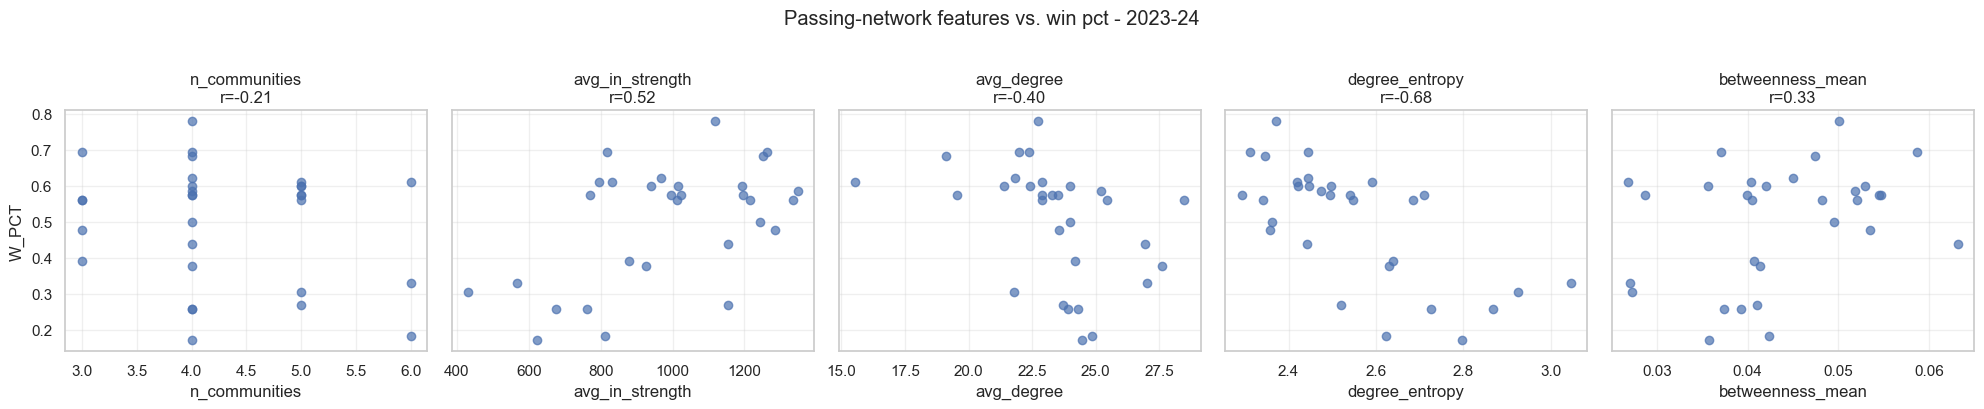

In [10]:
# Hypothesis scatter: does each feature track win pct?
features = ["n_communities", "avg_in_strength", "avg_degree",
            "degree_entropy", "betweenness_mean"]
fig, axes = plt.subplots(1, len(features), figsize=(4 * len(features), 4), sharey=True)
for ax, feat in zip(axes, features):
    ax.scatter(team_df[feat], team_df["W_PCT"], alpha=0.7)
    if team_df[feat].notna().sum() > 2:
        corr = team_df[[feat, "W_PCT"]].corr().iloc[0, 1]
        ax.set_title(f"{feat}\nr={corr:.2f}")
    else:
        ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("W_PCT")
fig.suptitle(f"Passing-network features vs. win pct - {SEASON}", y=1.02)
plt.tight_layout()


### Rotation filter sweep (addresses the confound)

Baseline correlations contradict Yang's hypothesis on `n_communities`, `avg_degree`, and `degree_entropy` — they correlate **negatively** with W_PCT. The cause is roster size: bad teams use more players (DET=30 nodes, MEM=33, vs. BOS=19), and more nodes mechanically inflates entropy and community count.

Yang's `2/3-man lineup` directive is the same idea as filtering: keep only the rotation. Let's sweep `min_mpg ∈ {0, 8, 12, 16, 20}` and see at what threshold the hypothesis stops being confounded.


In [11]:
FEATURES = ["n_nodes", "n_communities", "avg_in_strength", "avg_degree",
            "degree_entropy", "betweenness_max", "betweenness_mean"]
THRESHOLDS = [0, 8, 12, 16, 20]

sweep = []
sweep_dfs = {}
for mpg in THRESHOLDS:
    df = season_team_features(SEASON, min_mpg=mpg)
    sweep_dfs[mpg] = df
    row = {"min_mpg": mpg, "mean_n_nodes": df["n_nodes"].mean()}
    for feat in FEATURES:
        row[feat] = df[[feat, "W_PCT"]].corr().iloc[0, 1] if df[feat].notna().sum() > 2 else np.nan
    sweep.append(row)

sweep_df = pd.DataFrame(sweep).set_index("min_mpg")
print(f"Pearson r vs W_PCT for {SEASON}, by minutes-per-game cutoff:")
display(sweep_df.round(3))


Pearson r vs W_PCT for 2023-24, by minutes-per-game cutoff:


,mean_n_nodes,n_nodes,n_communities,avg_in_strength,avg_degree,degree_entropy,betweenness_max,betweenness_mean
min_mpg,,,,,,,,
0,21.900,-0.525,-0.205,0.523,-0.402,-0.679,0.191,0.333
8,15.667,-0.754,-0.346,0.689,-0.474,-0.638,0.284,0.461
12,13.067,-0.712,-0.635,0.719,-0.556,-0.607,0.193,0.355
16,10.433,-0.425,-0.219,0.606,-0.217,-0.351,0.063,0.211
20,8.200,-0.277,-0.058,0.625,-0.059,-0.183,-0.002,0.157


### Cross-season replication (2013-14 → 2025-26)

Same sweep, run across every season we have passing data for. Two views:

1. **Per-season r at mpg=12** — does any single feature flip signs across seasons? Is 2023-24 representative?
2. **Mean r across seasons, per (feature, mpg) cell** — which threshold gives the most stable signal?


In [12]:
import time

ALL_SEASONS = [f"{y}-{str(y + 1)[-2:]}" for y in range(2013, 2026)]
ALL_THRESHOLDS = [0, 8, 12, 16, 20]

# Build feature DataFrames for every (season, mpg) cell. Slow-ish (~100s on first run).
t0 = time.time()
season_features = {}  # (season, mpg) -> DataFrame
for season in ALL_SEASONS:
    for mpg in ALL_THRESHOLDS:
        season_features[(season, mpg)] = season_team_features(season, min_mpg=mpg)
    print(f"  {season} done ({time.time()-t0:.0f}s elapsed)", flush=True)
print(f"Total: {time.time()-t0:.0f}s")


  2013-14 done (8s elapsed)


  2014-15 done (16s elapsed)


  2015-16 done (24s elapsed)


  2016-17 done (35s elapsed)


  2017-18 done (47s elapsed)


...

  2022-23 done (91s elapsed)


  2023-24 done (99s elapsed)


  2024-25 done (108s elapsed)


  2025-26 done (117s elapsed)


Total: 117s


In [13]:
# View 1: per-season r at min_mpg=12 (the threshold that maximized signal in 2023-24)
TARGET_MPG = 12

per_season = []
for season in ALL_SEASONS:
    df = season_features[(season, TARGET_MPG)]
    row = {"season": season}
    for feat in FEATURES:
        if df[feat].notna().sum() > 2:
            row[feat] = df[[feat, "W_PCT"]].corr().iloc[0, 1]
    per_season.append(row)
per_season_df = pd.DataFrame(per_season).set_index("season")
print(f"Pearson r vs W_PCT, min_mpg={TARGET_MPG}, by season:")
display(per_season_df.round(2))

# Stability summary: mean +/- std, and "sign agreement" across seasons
summary = pd.DataFrame({
    "mean_r": per_season_df.mean(),
    "std_r": per_season_df.std(),
    "frac_pos": (per_season_df > 0).mean(),
})
print(f"\nStability across {len(ALL_SEASONS)} seasons:")
display(summary.round(3))


Pearson r vs W_PCT, min_mpg=12, by season:


,n_nodes,n_communities,avg_in_strength,avg_degree,degree_entropy,betweenness_max,betweenness_mean
season,,,,,,,
2013-14,-0.26,0.02,0.52,-0.25,-0.20,-0.08,0.12
2014-15,-0.57,-0.11,0.64,-0.40,-0.58,0.09,0.41
2015-16,-0.41,-0.22,0.32,-0.50,-0.46,0.21,0.57
2016-17,-0.34,-0.03,0.47,-0.18,-0.23,0.21,0.08
2017-18,-0.63,-0.28,0.52,-0.60,-0.58,0.07,0.20
2018-19,-0.46,-0.31,0.56,-0.45,-0.57,-0.07,0.28
2019-20,-0.33,-0.47,0.66,-0.21,-0.27,0.11,0.09
2020-21,-0.62,-0.26,0.60,-0.65,-0.64,0.28,0.30
2021-22,-0.60,-0.44,0.57,-0.46,-0.56,0.22,0.44



Stability across 13 seasons:


,mean_r,std_r,frac_pos
n_nodes,-0.521,0.171,0.000
n_communities,-0.321,0.216,0.077
avg_in_strength,0.553,0.122,1.000
avg_degree,-0.451,0.184,0.000
degree_entropy,-0.503,0.170,0.000
betweenness_max,0.110,0.110,0.846
betweenness_mean,0.316,0.158,1.000


Pooled n = 390 team-seasons


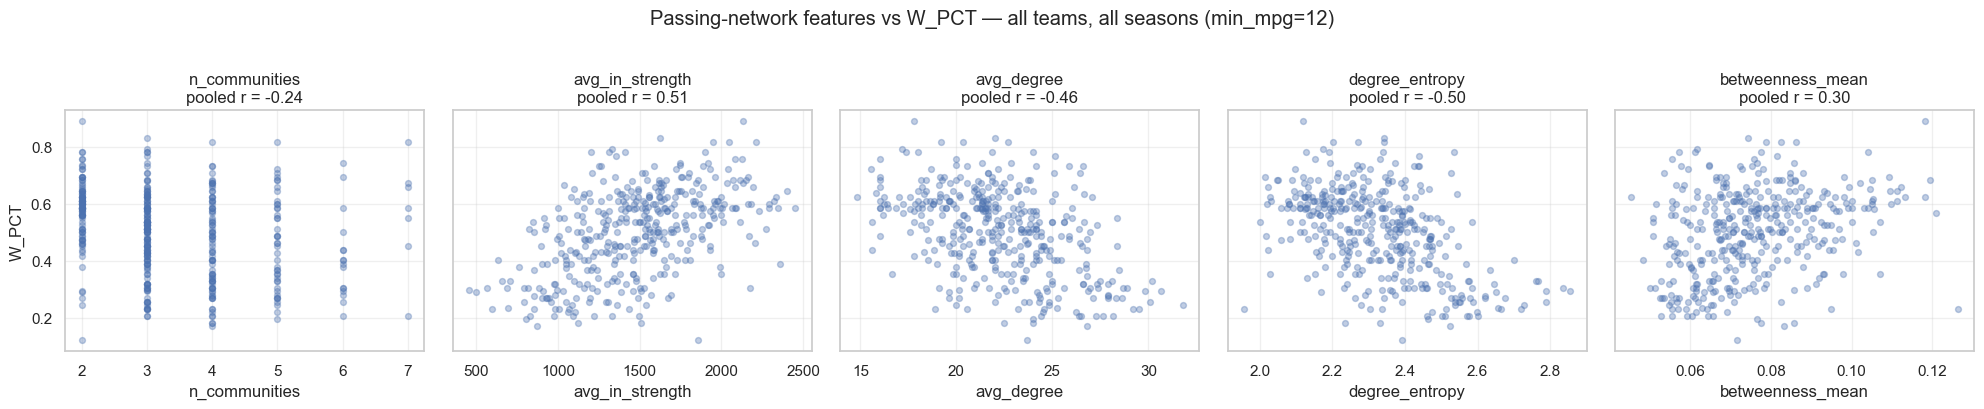

In [14]:
# View 2: pooled cross-season scatter at min_mpg=12 (390 team-seasons)
#   Each dot = one (team, season). Helps see whether avg_in_strength etc.
#   actually generalises.
pooled = pd.concat([season_features[(s, TARGET_MPG)].assign(season=s) for s in ALL_SEASONS],
                   ignore_index=True)
print(f"Pooled n = {len(pooled)} team-seasons")

import matplotlib.pyplot as plt
plot_feats = ["n_communities", "avg_in_strength", "avg_degree",
              "degree_entropy", "betweenness_mean"]
fig, axes = plt.subplots(1, len(plot_feats), figsize=(4 * len(plot_feats), 4), sharey=True)
for ax, feat in zip(axes, plot_feats):
    ax.scatter(pooled[feat], pooled["W_PCT"], alpha=0.35, s=18)
    r = pooled[[feat, "W_PCT"]].corr().iloc[0, 1]
    ax.set_title(f"{feat}\npooled r = {r:.2f}")
    ax.set_xlabel(feat)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("W_PCT")
fig.suptitle(f"Passing-network features vs W_PCT — all teams, all seasons (min_mpg={TARGET_MPG})", y=1.02)
plt.tight_layout()


In [15]:
# View 3: mean correlation across seasons, per (feature, mpg) cell.
# Tells us which threshold gives the most consistent positive signal.
cells = []
for season in ALL_SEASONS:
    for mpg in ALL_THRESHOLDS:
        df = season_features[(season, mpg)]
        row = {"season": season, "min_mpg": mpg}
        for feat in FEATURES:
            if df[feat].notna().sum() > 2:
                row[feat] = df[[feat, "W_PCT"]].corr().iloc[0, 1]
        cells.append(row)
cells_df = pd.DataFrame(cells)

mean_r = cells_df.groupby("min_mpg")[FEATURES].mean()
print(f"Mean Pearson r vs W_PCT across {len(ALL_SEASONS)} seasons, by threshold:")
display(mean_r.round(3))

# Heatmap-style: sign agreement (fraction of seasons with r > 0)
sign_agree = cells_df.groupby("min_mpg")[FEATURES].apply(lambda g: (g > 0).mean())
print(f"\nFraction of seasons with positive r (>= 0.5 means: 'usually positive'):")
display(sign_agree.round(2))


Mean Pearson r vs W_PCT across 13 seasons, by threshold:


,n_nodes,n_communities,avg_in_strength,avg_degree,degree_entropy,betweenness_max,betweenness_mean
min_mpg,,,,,,,
0,-0.344,-0.127,0.382,-0.140,-0.553,0.124,0.338
8,-0.424,-0.198,0.503,-0.259,-0.441,0.125,0.316
12,-0.521,-0.321,0.553,-0.451,-0.503,0.110,0.316
16,-0.408,-0.258,0.525,-0.348,-0.399,0.111,0.232
20,-0.272,-0.109,0.518,-0.218,-0.264,0.077,0.079



Fraction of seasons with positive r (>= 0.5 means: 'usually positive'):


,n_nodes,n_communities,avg_in_strength,avg_degree,degree_entropy,betweenness_max,betweenness_mean
min_mpg,,,,,,,
0,0.00,0.15,1.0,0.38,0.00,0.69,1.00
8,0.00,0.23,1.0,0.15,0.00,0.69,0.92
12,0.00,0.08,1.0,0.00,0.00,0.85,1.00
16,0.00,0.15,1.0,0.00,0.00,0.85,0.85
20,0.08,0.31,1.0,0.15,0.08,0.54,0.54


## 2.6 — Win-prob mapping (benchmark = best team, per Yang's directive)

Yang's plan: *"benchmark the best team with winning prob of 1, then mapping the others' prob with the distance to the best one."* Now that we have validated signals (`avg_in_strength`, `betweenness_mean`), we can build that mapping and see how well it tracks actual `W_PCT`.

**Setup:**
- Per season: z-score features within the season (so 2017-18 and 2023-24 are comparable).
- Benchmark = team with highest `W_PCT`. Win prob = 1.
- Distance: Euclidean in z-scored feature space.
- Mapping `d → prob`: try a few — inverse `1/(1+d)`, exponential `exp(-d/τ)`, and a linear `1 - d/max(d)` for comparison.
- Diagnostic: Spearman rank correlation against actual `W_PCT`.


In [16]:
from scipy.stats import spearmanr

VALIDATED_FEATS = ["avg_in_strength", "betweenness_mean"]


def benchmark_winprob(df, feats=VALIDATED_FEATS, mapping="inverse", tau=1.0):
    """Per-season: z-score feats, anchor on best team (W_PCT max),
    return df with columns dist_to_best and pred_winprob.

    mapping options:
      - 'inverse' : prob = 1 / (1 + dist)
      - 'exp'     : prob = exp(-dist / tau)
      - 'linear'  : prob = 1 - dist / dist.max()
    """
    df = df.copy()
    X = df[feats].to_numpy(dtype=float)
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0)
    sd[sd == 0] = 1.0
    Z = (X - mu) / sd
    best_idx = int(df["W_PCT"].idxmax())
    anchor = Z[best_idx]
    dist = np.linalg.norm(Z - anchor, axis=1)
    df["dist_to_best"] = dist
    if mapping == "inverse":
        df["pred_winprob"] = 1.0 / (1.0 + dist)
    elif mapping == "exp":
        df["pred_winprob"] = np.exp(-dist / tau)
    elif mapping == "linear":
        m = dist.max() or 1.0
        df["pred_winprob"] = 1.0 - dist / m
    else:
        raise ValueError(mapping)
    return df


# Run per season for each candidate mapping; report Spearman rho of pred vs actual W_PCT.
mapping_rows = []
for mapping in ["inverse", "exp", "linear"]:
    per_season = []
    for season in ALL_SEASONS:
        df = season_features[(season, 12)]
        df_m = benchmark_winprob(df, mapping=mapping)
        rho = spearmanr(df_m["pred_winprob"], df_m["W_PCT"]).statistic
        per_season.append({"season": season, "rho": rho})
    per = pd.DataFrame(per_season).set_index("season")
    mapping_rows.append({
        "mapping": mapping,
        "mean_rho": per["rho"].mean(),
        "std_rho": per["rho"].std(),
        "min_rho": per["rho"].min(),
        "max_rho": per["rho"].max(),
    })
mapping_df = pd.DataFrame(mapping_rows).set_index("mapping")
print(f"Spearman rho(pred_winprob, W_PCT), 2 features, min_mpg=12, n=30 teams per season:")
display(mapping_df.round(3))


Spearman rho(pred_winprob, W_PCT), 2 features, min_mpg=12, n=30 teams per season:


,mean_rho,std_rho,min_rho,max_rho
mapping,,,,
inverse,0.199,0.398,-0.465,0.647
exp,0.199,0.398,-0.465,0.647
linear,0.199,0.398,-0.465,0.647


team              TEAM_NAME  W_PCT  dist_to_best  pred_winprob
 OKC  Oklahoma City Thunder  0.829         0.000         1.000
 CLE    Cleveland Cavaliers  0.780         1.581         0.387
 BOS         Boston Celtics  0.744         0.930         0.518
 HOU        Houston Rockets  0.634         0.698         0.589
 NYK        New York Knicks  0.622         0.583         0.632
 LAC            LA Clippers  0.610         2.800         0.263
 LAL     Los Angeles Lakers  0.610         1.422         0.413
 DEN         Denver Nuggets  0.610         2.506         0.285
 IND         Indiana Pacers  0.610         1.082         0.480
 MIN Minnesota Timberwolves  0.598         1.972         0.336
 GSW  Golden State Warriors  0.585         0.320         0.758
 MIL        Milwaukee Bucks  0.585         0.727         0.579
 MEM      Memphis Grizzlies  0.585         1.867         0.349
 DET        Detroit Pistons  0.537         0.908         0.524
 ORL          Orlando Magic  0.500         1.494       

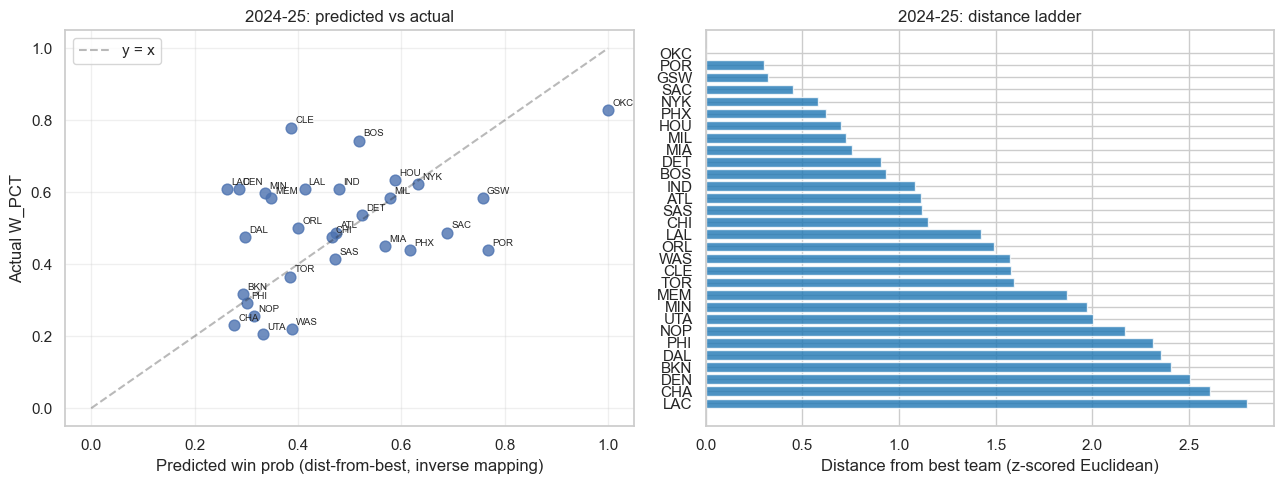

In [17]:
# Visual: per-team predicted vs actual W_PCT, latest season
SEASON_SHOW = "2024-25"
df_show = benchmark_winprob(season_features[(SEASON_SHOW, 12)], mapping="inverse")
df_show = df_show.sort_values("W_PCT", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df_show["pred_winprob"], df_show["W_PCT"], s=60, alpha=0.8)
for _, r in df_show.iterrows():
    axes[0].annotate(r["team"], (r["pred_winprob"], r["W_PCT"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="y = x")
axes[0].set_xlabel("Predicted win prob (dist-from-best, inverse mapping)")
axes[0].set_ylabel("Actual W_PCT")
axes[0].set_title(f"{SEASON_SHOW}: predicted vs actual")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bar chart: distance from best team
df_d = df_show.sort_values("dist_to_best")
axes[1].barh(df_d["team"], df_d["dist_to_best"], color="#1f77b4", alpha=0.8)
axes[1].set_xlabel("Distance from best team (z-scored Euclidean)")
axes[1].set_title(f"{SEASON_SHOW}: distance ladder")
axes[1].invert_yaxis()
plt.tight_layout()

print(df_show[["team", "TEAM_NAME", "W_PCT", "dist_to_best", "pred_winprob"]].round(3).to_string(index=False))


### Diagnosis — why distance-from-best underperforms

Spearman ρ = 0.20 (std 0.40) is much worse than the +0.55 we get from `avg_in_strength` alone. The mappings all give the same ρ because they're monotone transforms of distance; the problem is the **distance metric itself**.

Hypothesis: the best team isn't an *extreme* in feature space — two great teams (e.g., OKC pass-heavy + CLE star-isolation) can have very different profiles, so Euclidean distance to a single anchor punishes other contenders that play differently.

Let's compare four approaches per season:

1. **single-feature**: rank teams directly by `avg_in_strength`.
2. **dist-from-best-1**: current approach (Yang's framework).
3. **dist-from-top-3 centroid**: anchor on mean of top-3 W_PCT teams.
4. **linear regression**: fit `W_PCT ~ avg_in_strength + betweenness_mean` within season, use fitted values.


In [18]:
from sklearn.linear_model import LinearRegression


def score_season(df, method, feats=VALIDATED_FEATS):
    """Return predicted ordering signal (higher = better) for a season df."""
    df = df.copy()
    X = df[feats].to_numpy(dtype=float)
    mu = X.mean(axis=0); sd = X.std(axis=0, ddof=0); sd[sd == 0] = 1.0
    Z = (X - mu) / sd
    y = df["W_PCT"].to_numpy()

    if method == "single-feature":
        return Z[:, feats.index("avg_in_strength")]
    if method == "dist-from-best-1":
        anchor = Z[int(np.argmax(y))]
        return -np.linalg.norm(Z - anchor, axis=1)
    if method == "dist-from-top3":
        top3 = np.argsort(-y)[:3]
        anchor = Z[top3].mean(axis=0)
        return -np.linalg.norm(Z - anchor, axis=1)
    if method == "linreg":
        reg = LinearRegression().fit(Z, y)
        return reg.predict(Z)
    raise ValueError(method)


methods = ["single-feature", "dist-from-best-1", "dist-from-top3", "linreg"]
rows = []
per_season_rhos = {m: [] for m in methods}
for season in ALL_SEASONS:
    df = season_features[(season, 12)]
    for m in methods:
        pred = score_season(df, m)
        rho = spearmanr(pred, df["W_PCT"]).statistic
        per_season_rhos[m].append(rho)

cmp = pd.DataFrame({
    m: {
        "mean_rho": float(np.mean(per_season_rhos[m])),
        "std_rho":  float(np.std(per_season_rhos[m], ddof=1)),
        "min_rho":  float(np.min(per_season_rhos[m])),
        "max_rho":  float(np.max(per_season_rhos[m])),
        "frac_pos": float(np.mean([r > 0 for r in per_season_rhos[m]])),
    } for m in methods
}).T
print(f"Spearman rho vs W_PCT, 13 seasons, min_mpg=12:")
display(cmp.round(3))

# Per-season detail
detail = pd.DataFrame(per_season_rhos, index=ALL_SEASONS).round(2)
print("\nPer-season breakdown:")
display(detail)


Spearman rho vs W_PCT, 13 seasons, min_mpg=12:


,mean_rho,std_rho,min_rho,max_rho,frac_pos
single-feature,0.531,0.097,0.367,0.705,1.000
dist-from-best-1,0.199,0.398,-0.465,0.647,0.692
dist-from-top3,0.334,0.210,-0.044,0.611,0.923
linreg,0.594,0.088,0.436,0.721,1.000



Per-season breakdown:


,single-feature,dist-from-best-1,dist-from-top3,linreg
2013-14,0.52,0.46,0.51,0.53
2014-15,0.60,0.63,0.61,0.70
2015-16,0.39,0.65,0.57,0.68
2016-17,0.41,0.27,0.21,0.44
2017-18,0.51,-0.46,0.20,0.57
2018-19,0.55,-0.20,0.10,0.58
2019-20,0.61,0.15,0.13,0.61
2020-21,0.52,0.36,0.44,0.57
2021-22,0.58,0.44,0.48,0.63
2022-23,0.37,-0.28,-0.04,0.44


### Out-of-sample predictive test

The within-season linreg above is *explanatory* (fit and evaluate on the same data). For the trading strategy we need forward prediction: at the start of season N, we only have features and outcomes from seasons < N. Expanding-window evaluation: train on `seasons[:i]`, predict `season[i]`.

Two variants:
- **OOS pooled**: train on raw features (preserves any year-over-year drift in passing volume).
- **OOS within-season z-score**: z-score features within each season before pooling (assumes the *rank* relationship is stable, not the absolute scale).


In [19]:
def _within_season_z(X):
    mu = X.mean(axis=0); sd = X.std(axis=0, ddof=0); sd[sd == 0] = 1.0
    return (X - mu) / sd


def _standardize_train_test(X_train, X_test):
    mu = X_train.mean(axis=0); sd = X_train.std(axis=0, ddof=0); sd[sd == 0] = 1.0
    return (X_train - mu) / sd, (X_test - mu) / sd


oos = []
for i, test_s in enumerate(ALL_SEASONS):
    test_df = season_features[(test_s, 12)]
    y_te = test_df["W_PCT"].to_numpy()

    # In-sample baseline (same as the linreg row above, recomputed for alignment)
    X_in = _within_season_z(test_df[VALIDATED_FEATS].to_numpy())
    rho_in = spearmanr(LinearRegression().fit(X_in, y_te).predict(X_in), y_te).statistic

    row = {"season": test_s,
           "n_train_seasons": i,
           "rho_in_sample": rho_in,
           "rho_single_feat": spearmanr(test_df["avg_in_strength"], y_te).statistic}

    if i == 0:
        row["rho_oos_pooled"] = np.nan
        row["rho_oos_within"] = np.nan
    else:
        train_seasons = ALL_SEASONS[:i]
        train_df = pd.concat([season_features[(s, 12)] for s in train_seasons], ignore_index=True)
        y_tr = train_df["W_PCT"].to_numpy()

        # Pooled raw -> standardize using train stats
        X_tr, X_te = _standardize_train_test(
            train_df[VALIDATED_FEATS].to_numpy(),
            test_df[VALIDATED_FEATS].to_numpy(),
        )
        row["rho_oos_pooled"] = spearmanr(
            LinearRegression().fit(X_tr, y_tr).predict(X_te), y_te
        ).statistic

        # Within-season z-score each season independently, then pool
        X_tr_w = np.vstack([
            _within_season_z(season_features[(s, 12)][VALIDATED_FEATS].to_numpy())
            for s in train_seasons
        ])
        X_te_w = _within_season_z(test_df[VALIDATED_FEATS].to_numpy())
        row["rho_oos_within"] = spearmanr(
            LinearRegression().fit(X_tr_w, y_tr).predict(X_te_w), y_te
        ).statistic

    oos.append(row)

oos_df = pd.DataFrame(oos).set_index("season")
print("Per-season Spearman rho (expanding window OOS):")
display(oos_df.round(3))

# Aggregates over the 12 seasons we can score (drop 2013-14 — no training data)
methods = ["rho_in_sample", "rho_oos_pooled", "rho_oos_within", "rho_single_feat"]
agg = oos_df.iloc[1:][methods].agg(["mean", "std", "min", "max"]).round(3)
agg.loc["frac_pos"] = ((oos_df.iloc[1:][methods] > 0).mean()).round(3)
print(f"\nAggregates across {len(oos_df) - 1} test seasons:")
display(agg)


Per-season Spearman rho (expanding window OOS):


,n_train_seasons,rho_in_sample,rho_single_feat,rho_oos_pooled,rho_oos_within
season,,,,,
2013-14,0,0.527,0.523,NaN,NaN
2014-15,1,0.698,0.598,0.598,0.597
2015-16,2,0.681,0.387,0.455,0.490
2016-17,3,0.436,0.407,0.370,0.346
2017-18,4,0.574,0.511,0.571,0.588
2018-19,5,0.583,0.550,0.572,0.567
2019-20,6,0.614,0.615,0.640,0.644
2020-21,7,0.571,0.523,0.589,0.577
2021-22,8,0.627,0.576,0.624,0.617



Aggregates across 12 test seasons:


,rho_in_sample,rho_oos_pooled,rho_oos_within,rho_single_feat
mean,0.600,0.567,0.569,0.531
std,0.090,0.105,0.105,0.101
min,0.436,0.370,0.346,0.367
max,0.721,0.719,0.718,0.705
frac_pos,1.000,1.000,1.000,1.000


## 3 — Lineup network (shared-player edges)

In [20]:
GL = build_lineup_network(SEASON, TEAM, min_minutes=10.0)
comms = communities(GL)
color_map = {n: i for i, c in enumerate(comms) for n in c}
print(f"{TEAM} {SEASON} lineups: {GL.number_of_nodes()} nodes, {GL.number_of_edges()} edges, {len(comms)} communities")


BOS 2023-24 lineups: 91 nodes, 1753 edges, 3 communities


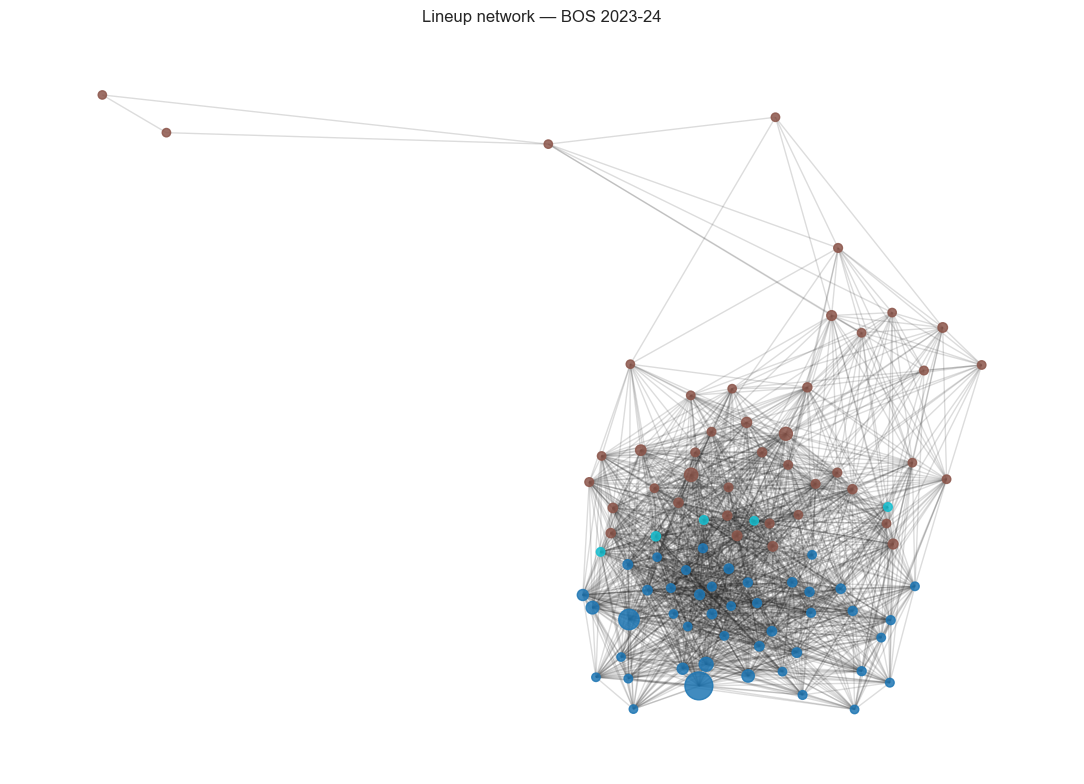

In [21]:
minutes = nx.get_node_attributes(GL, "minutes")
node_sizes = [30 + minutes.get(n,0)*0.6 for n in GL.nodes]
node_colors = [color_map.get(n, -1) for n in GL.nodes]
pos = nx.spring_layout(GL, seed=11, k=2/np.sqrt(max(GL.number_of_nodes(),1)))

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(GL, pos, alpha=0.15, ax=ax)
nx.draw_networkx_nodes(GL, pos, node_size=node_sizes, node_color=node_colors, cmap="tab10", alpha=0.85, ax=ax)
ax.set_title(f"Lineup network — {TEAM} {SEASON}")
ax.axis("off")
plt.tight_layout()


## 3.5 — Lineup co-occurrence network (Yang's 2/3-man directive)

Yang asked us to try 2-man and 3-man lineups instead of 5-man (more minutes per lineup, less in-game churn). Re-scraped via `nba_api` with `group_quantity in {2, 3}` and built **player-level co-occurrence graphs**: nodes = players, edges = joint minutes in any N-man unit. Cleaner than the lineup-level graph in section 3 because nodes are players, so it's directly comparable to the passing network.

**Headline question:** do lineup features add OOS signal beyond `avg_in_strength` + `betweenness_mean`?

**Spoiler:** g2 ~ g3 (correlation ~1.0 on the 4-season overlap), so we run the full 13-season test on 2-man.


In [22]:
from src.network.builders import build_player_cooccurrence_network


def lineup_team_features(season, team, group_quantity=2, min_minutes=5.0):
    g = build_player_cooccurrence_network(season, team, min_minutes=min_minutes,
                                          group_quantity=group_quantity)
    if g.number_of_nodes() == 0:
        return None
    strengths = [d for _, d in g.degree(weight="weight")]
    comms = louvain_partition(g, seed=0)
    return {
        "linup_avg_strength": float(np.mean(strengths)),
        "linup_max_strength": float(np.max(strengths)),
        "linup_entropy":      degree_entropy(g, weight="weight"),
        "linup_n_comm":       len(comms),
        "linup_n_nodes":      g.number_of_nodes(),
        "linup_density":      nx.density(g),
    }


def season_pool_with_lineup(season):
    """Per-team features combining passing + 2-man lineup + W_PCT."""
    pass_df = season_features[(season, 12)]
    rows = []
    for _, r in pass_df.iterrows():
        lf = lineup_team_features(season, r["team"], group_quantity=2)
        if lf is None:
            continue
        row = {**r.to_dict(), **lf}
        rows.append(row)
    return pd.DataFrame(rows)


import time
t0 = time.time()
lineup_pool = {s: season_pool_with_lineup(s) for s in ALL_SEASONS}
print(f"Built passing+lineup features for {len(lineup_pool)} seasons in {time.time()-t0:.0f}s")
print(f"Teams per season: {[len(lineup_pool[s]) for s in ALL_SEASONS]}")


Built passing+lineup features for 13 seasons in 64s
Teams per season: [30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30]


### Per-feature correlation (sanity)

First, do the lineup features even correlate with W_PCT, and in the same direction as the passing features?


In [23]:
LINUP_FEATS = ["linup_avg_strength", "linup_max_strength", "linup_entropy",
               "linup_n_comm", "linup_n_nodes", "linup_density"]
PASS_FEATS  = VALIDATED_FEATS  # avg_in_strength + betweenness_mean

rows = []
for s in ALL_SEASONS:
    df = lineup_pool[s]
    row = {"season": s}
    for f in PASS_FEATS + LINUP_FEATS:
        if df[f].notna().sum() > 2:
            row[f] = df[[f, "W_PCT"]].corr().iloc[0, 1]
    rows.append(row)
corr_df = pd.DataFrame(rows).set_index("season")
summary = pd.DataFrame({
    "mean_r":   corr_df.mean(),
    "std_r":    corr_df.std(),
    "frac_pos": (corr_df > 0).mean(),
}).round(3)
print("Per-feature Pearson r vs W_PCT, 13 seasons:")
display(summary)


Per-feature Pearson r vs W_PCT, 13 seasons:


,mean_r,std_r,frac_pos
avg_in_strength,0.553,0.122,1.000
betweenness_mean,0.316,0.158,1.000
linup_avg_strength,0.363,0.129,1.000
linup_max_strength,0.402,0.106,1.000
linup_entropy,-0.556,0.133,0.000
linup_n_comm,-0.224,0.164,0.077
linup_n_nodes,-0.355,0.131,0.000
linup_density,0.156,0.136,0.846


### OOS expanding-window test

Train on prior seasons, predict held-out. Compare three feature sets: passing-only, lineup-only, combined.


In [24]:
def oos_predict(feats_to_use):
    rhos = []
    for i in range(1, len(ALL_SEASONS)):
        train = pd.concat([lineup_pool[s] for s in ALL_SEASONS[:i]], ignore_index=True)
        test  = lineup_pool[ALL_SEASONS[i]]
        if test.empty or train.empty:
            continue
        Xtr = train[feats_to_use].to_numpy(); ytr = train["W_PCT"].to_numpy()
        Xte = test[feats_to_use].to_numpy();  yte = test["W_PCT"].to_numpy()
        mu = Xtr.mean(axis=0); sd = Xtr.std(axis=0, ddof=0); sd[sd==0]=1.0
        Xtr=(Xtr-mu)/sd; Xte=(Xte-mu)/sd
        pred = LinearRegression().fit(Xtr, ytr).predict(Xte)
        rhos.append({"season": ALL_SEASONS[i], "rho": spearmanr(pred, yte).statistic})
    return pd.DataFrame(rhos).set_index("season")["rho"]


cmp = pd.DataFrame({
    "pass_only":  oos_predict(PASS_FEATS),
    "linup_only": oos_predict(LINUP_FEATS),
    "combined":   oos_predict(PASS_FEATS + LINUP_FEATS),
})
cmp["delta_lineup_help"] = cmp["combined"] - cmp["pass_only"]
print("Per-season OOS Spearman rho:")
display(cmp.round(3))

agg = cmp[["pass_only", "linup_only", "combined"]].agg(["mean", "std", "min", "max"]).round(3)
agg.loc["frac_pos"] = (cmp[["pass_only", "linup_only", "combined"]] > 0).mean().round(3)
print(f"\nAggregates across {len(cmp)} test seasons:")
display(agg)
print(f"\nMean delta (combined - pass_only): {cmp['delta_lineup_help'].mean():+.4f}")
print(f"Seasons where lineup HELPS: {int((cmp['delta_lineup_help'] > 0).sum())}/{len(cmp)}")


Per-season OOS Spearman rho:

,pass_only,linup_only,combined,delta_lineup_help
season,,,,
2014-15,0.598,0.542,0.631,0.033
2015-16,0.455,0.423,0.301,-0.154
2016-17,0.370,0.374,0.452,0.081
2017-18,0.571,0.510,0.568,-0.003
2018-19,0.572,0.626,0.641,0.070
2019-20,0.640,0.404,0.520,-0.120
2020-21,0.589,0.617,0.637,0.048
2021-22,0.624,0.587,0.677,0.053
2022-23,0.405,0.332,0.371,-0.034



Aggregates across 12 test seasons:


,pass_only,linup_only,combined
mean,0.567,0.531,0.570
std,0.105,0.127,0.143
min,0.370,0.332,0.301
max,0.719,0.746,0.757
frac_pos,1.000,1.000,1.000



Mean delta (combined - pass_only): +0.0024
Seasons where lineup HELPS: 7/12


## 4 — Yu & Yang utility network (Havel-Hakimi)

In [25]:
GU = build_utility_network(SEASON, TEAM)
util = pd.DataFrame([{"player": d["name"], "utility": d["utility"]} for _, d in GU.nodes(data=True)]).sort_values("utility", ascending=False)
display(util)


,player,utility
5,Jayson Tatum,0.847297
1,Derrick White,0.745832
4,Jaylen Brown,0.745477
8,Kristaps Porziņģis,0.696089
7,Jrue Holiday,0.688678
0,Al Horford,0.550426
12,Payton Pritchard,0.445132
16,Xavier Tillman,0.418897
13,Sam Hauser,0.385342
9,Luke Kornet,0.353560


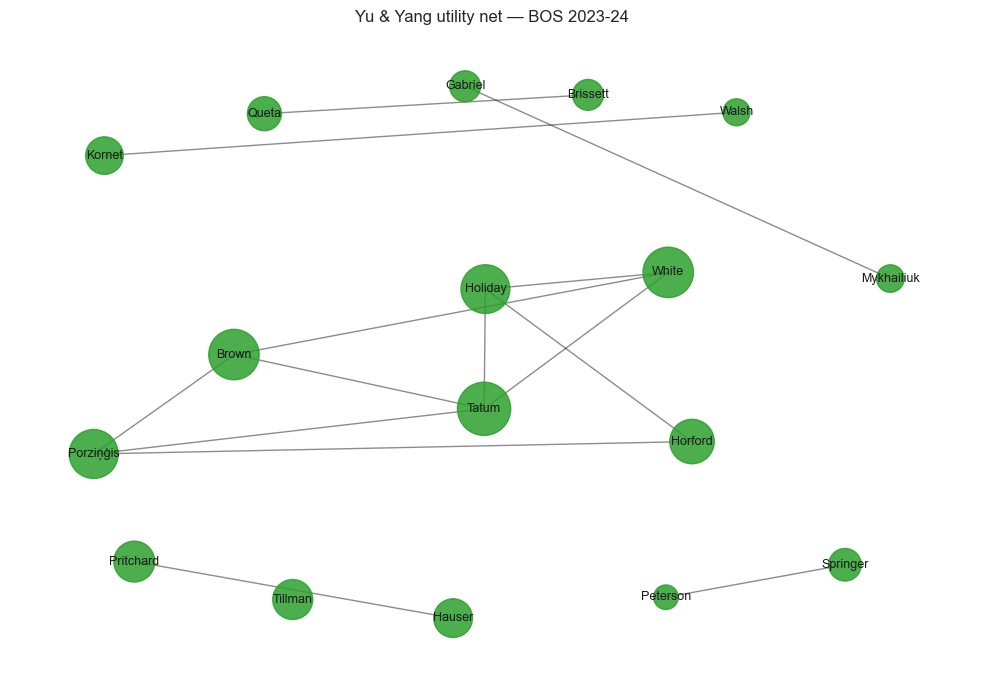

In [26]:
pos = nx.spring_layout(GU, seed=4, k=1.5)
util_vals = nx.get_node_attributes(GU, "utility")
node_sizes = [200 + util_vals[n]*1500 for n in GU.nodes]
labels = {n: GU.nodes[n]["name"].split()[-1] for n in GU.nodes}

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_edges(GU, pos, alpha=0.5, ax=ax)
nx.draw_networkx_nodes(GU, pos, node_size=node_sizes, node_color="#2ca02c", alpha=0.85, ax=ax)
nx.draw_networkx_labels(GU, pos, labels=labels, font_size=9, ax=ax)
ax.set_title(f"Yu & Yang utility net — {TEAM} {SEASON}")
ax.axis("off")
plt.tight_layout()


## 5 — Team similarity network

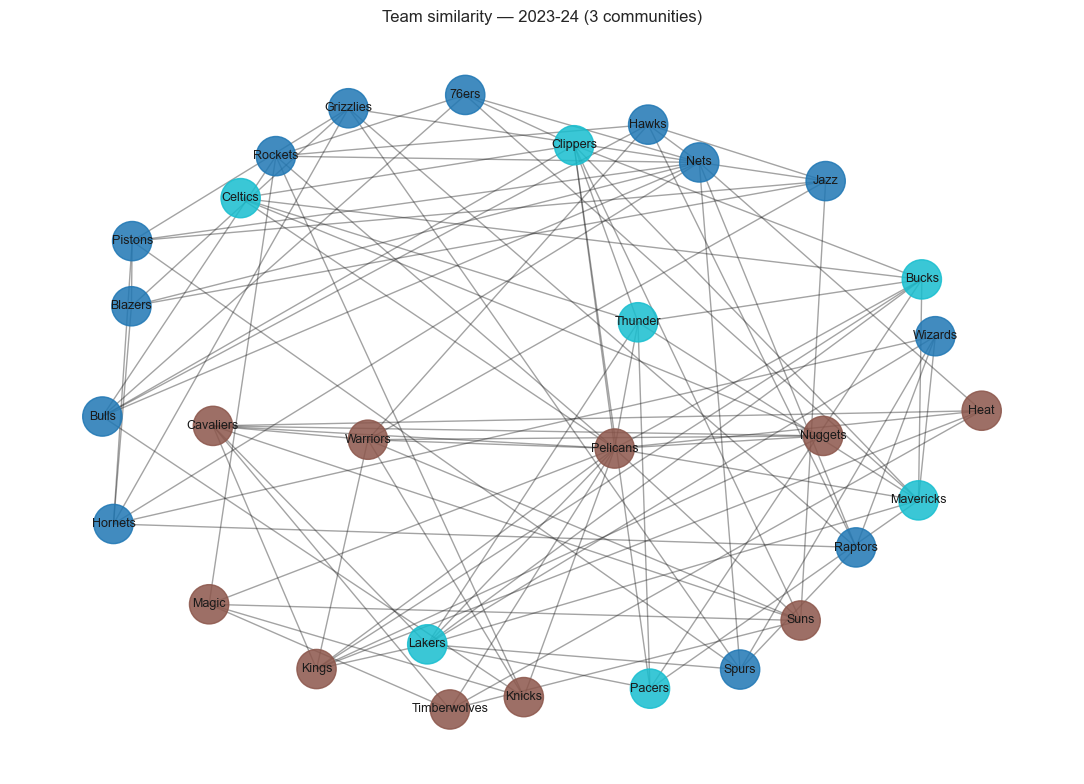

In [27]:
GT = build_team_network(SEASON, k_neighbors=5)
comms_t = communities(GT)
color_map_t = {n: i for i, c in enumerate(comms_t) for n in c}
pos = nx.spring_layout(GT, seed=3, weight="weight", k=1.5)
labels = {n: GT.nodes[n]["name"].split(" ")[-1] for n in GT.nodes}
colors = [color_map_t[n] for n in GT.nodes]

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(GT, pos, alpha=0.4, ax=ax)
nx.draw_networkx_nodes(GT, pos, node_size=800, node_color=colors, cmap="tab10", alpha=0.85, ax=ax)
nx.draw_networkx_labels(GT, pos, labels=labels, font_size=9, ax=ax)
ax.set_title(f"Team similarity — {SEASON} ({len(comms_t)} communities)")
ax.axis("off")
plt.tight_layout()
